# Milestone 1: setup and data loading

Source: [Football-Data](https://www.football-data.co.uk/englandm.php). See `../docs/PRD.md` v2.0. This notebook validates all seasons structurally and describes training rows only. No features or models yet.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "src").is_dir():
    ROOT = ROOT.parent
if not (ROOT / "src/data.py").is_file():
    raise RuntimeError("Open this notebook from the repository or notebooks folder")
sys.path.insert(0, str(ROOT))
from src.data import load_data
import json
import pandas as pd

In [2]:
report = json.loads((ROOT / "reports/data_summary.json").read_text())
seasons = report["seasons"]
print("Previously verified milestone 1 structural snapshot; final-test CSVs are not opened.")
display(pd.DataFrame(seasons).drop(columns="raw_columns"))
print("Validated rows:", report["total_rows"])
print("Required columns:", report["required_columns"])
print("Loaded columns:", report["loaded_columns"])

Previously verified milestone 1 structural snapshot; final-test CSVs are not opened.
Validated rows: 4560
Required columns: ['Date', 'HomeTeam', 'AwayTeam', 'FTR', 'FTHG', 'FTAG']
Loaded columns: ['Div', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'Referee', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'B365H', 'B365D', 'B365A', 'BWH', 'BWD', 'BWA', 'IWH', 'IWD', 'IWA', 'LBH', 'LBD', 'LBA', 'PSH', 'PSD', 'PSA', 'WHH', 'WHD', 'WHA', 'SJH', 'SJD', 'SJA', 'VCH', 'VCD', 'VCA', 'Bb1X2', 'BbMxH', 'BbAvH', 'BbMxD', 'BbAvD', 'BbMxA', 'BbAvA', 'BbOU', 'BbMx>2.5', 'BbAv>2.5', 'BbMx<2.5', 'BbAv<2.5', 'BbAH', 'BbAHh', 'BbMxAHH', 'BbAvAHH', 'BbMxAHA', 'BbAvAHA', 'PSCH', 'PSCD', 'PSCA', 'Season', 'Time', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'B365>2.5', 'B365<2.5', 'P>2.5', 'P<2.5', 'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5', 'AHh', 'B365AHH', 'B365AHA', 'PAHH', 'PAHA', 'MaxAHH', 'MaxAHA', 'AvgAHH', 'AvgAHA', 'B365CH', 'B365CD'

,season,split,raw_rows,rows,identical_duplicates_removed,blank_rows_removed,columns,first_date,last_date,valid_b365_rows,expected_380
0,2014/15,train,381,380,0,1,68,2014-08-16,2015-05-24,380,True
1,2015/16,train,380,380,0,0,65,2015-08-08,2016-05-17,380,True
2,2016/17,train,380,380,0,0,65,2016-08-13,2017-05-21,380,True
3,2017/18,train,380,380,0,0,65,2017-08-11,2018-05-13,380,True
4,2018/19,train,380,380,0,0,62,2018-08-10,2019-05-12,380,True
5,2019/20,train,380,380,0,0,106,2019-08-09,2020-07-26,380,True
6,2020/21,train,380,380,0,0,106,2020-09-12,2021-05-23,380,True
7,2021/22,train,380,380,0,0,106,2021-08-13,2022-05-22,380,True
8,2022/23,train,380,380,0,0,106,2022-08-05,2023-05-28,380,True
9,2023/24,validation,380,380,0,0,106,2023-08-11,2024-05-19,380,True


In [3]:
display(pd.DataFrame({"count": report["training_result_counts"], "frequency": report["training_result_frequencies"]}))
display(pd.DataFrame([report["training_example"]]))

,count,frequency
H,1533,0.448246
D,804,0.235088
A,1083,0.316667


,Season,Date,HomeTeam,AwayTeam,FTR,FTHG,FTAG
0,2014/15,2014-08-16,Arsenal,Crystal Palace,H,2,1


One row is one finished fixture. `FTHG` and `FTAG` are full-time home and away goals; `FTR` is H (home win), D (draw), or A (away win). These are labels/history after the match, so using them to predict that same fixture would leak its answer. Missing odds affect later benchmark coverage, not match eligibility. Hashes in `data/sources.json` identify the exact bytes; a provider correction can change a future download.

In [4]:
import json
sources = json.loads((ROOT / "data/sources.json").read_text())
display(pd.DataFrame.from_dict(sources, orient="index"))

,url,retrieved_at_utc,sha256,file
2014/15,https://www.football-data.co.uk/mmz4281/1415/E...,2026-10-07T01:16:11.376410+00:00,76b7858051ff6b17f46f49f26fdc70c1f2953727049260...,data/raw/E0_1415.csv
2015/16,https://www.football-data.co.uk/mmz4281/1516/E...,2026-10-07T01:16:12.790869+00:00,bd3502a18c38a1597fd9af62e2366b4015006d3528dd4d...,data/raw/E0_1516.csv
2016/17,https://www.football-data.co.uk/mmz4281/1617/E...,2026-10-07T01:16:14.186563+00:00,9625a7652b5f98fbd3e2e4d378c851fc246693f3343e34...,data/raw/E0_1617.csv
2017/18,https://www.football-data.co.uk/mmz4281/1718/E...,2026-10-07T01:16:15.650122+00:00,4f3389365ef3f7ac966764ed8ba67cf3b79f5aebed18dd...,data/raw/E0_1718.csv
2018/19,https://www.football-data.co.uk/mmz4281/1819/E...,2026-10-07T01:16:17.091126+00:00,7c096b3c2ecd54c6993d22eeea73450c2bde11e3457238...,data/raw/E0_1819.csv
2019/20,https://www.football-data.co.uk/mmz4281/1920/E...,2026-10-07T01:16:18.773711+00:00,100037618b94f94057400bb02bf6bac4ef74ddaa58cde4...,data/raw/E0_1920.csv
2020/21,https://www.football-data.co.uk/mmz4281/2021/E...,2026-10-07T01:16:20.315358+00:00,5afe63f69401457b8354eaacee24f9a3e520b3c3af6329...,data/raw/E0_2021.csv
2021/22,https://www.football-data.co.uk/mmz4281/2122/E...,2026-10-07T01:16:21.883477+00:00,335afcbabeb2939fa10ab39ba3e8215072d0b577cb8d07...,data/raw/E0_2122.csv
2022/23,https://www.football-data.co.uk/mmz4281/2223/E...,2026-10-07T01:16:23.429470+00:00,8442792d3b614c94ea3cf381bd2736805889cc17131690...,data/raw/E0_2223.csv
2023/24,https://www.football-data.co.uk/mmz4281/2324/E...,2026-10-07T01:16:24.984209+00:00,b2e057b0ed959f198b0f63d2391c01239f3608e6de5db6...,data/raw/E0_2324.csv


Understanding checkpoint:
1. Why would using this fixture’s FTHG or FTAG as inputs leak the answer?
2. If a match has valid results but missing B365 odds, should it be removed from model data? Why?

Milestone 2 was subsequently requested; continue to the section below.

## Milestone 2: probability baselines and metrics

This section loads **training seasons only (2014/15–2022/23)**. It fits fixed outcome frequencies and converts bookmaker odds; no classifier is trained, and no validation/test predictions are scored. The training scores below are illustrations, not held-out evidence. Every probability row uses **H, D, A** order.

In [5]:
import numpy as np
from src.metrics import (CLASS_ORDER, TRAIN_SEASONS, LOG_LOSS_EPSILON, baseline_report,
                         bookmaker_probabilities, multiclass_log_loss, ranked_probability_score)

train, _ = load_data(ROOT, seasons=TRAIN_SEASONS)
baselines = baseline_report(train)
display(pd.DataFrame({"count": baselines["training_counts"],
                      "fixed_probability": baselines["training_probabilities"]}))
print("Every fixture receives the same training-frequency probabilities.")
print("Bookmaker coverage:", baselines["bookmaker_matches"], "/", baselines["training_matches"])
display(pd.DataFrame(baselines["scores"]))
print(baselines["scope"])

Every fixture receives the same training-frequency probabilities.
Bookmaker coverage: 3420 / 3420
Training illustration only, not held-out evaluation; validation/test not loaded.


,count,fixed_probability
H,1533,0.448246
D,804,0.235088
A,1083,0.316667


,baseline,subset,matches,log_loss,rps
0,training_frequency,all_training,3420,1.064174,0.231855
1,training_frequency,training_with_valid_odds,3420,1.064174,0.231855
2,bookmaker,training_with_valid_odds,3420,0.959399,0.195566


### Hand calculation: synthetic odds 2, 3, 4; actual result D

Invert decimal odds in H D A order: **1/2, 1/3, 1/4**. Their sum is **13/12 = 1.083333**, so they do not yet sum to one. Divide each by 13/12 to obtain **6/13, 4/13, 3/13** (46.1538%, 30.7692%, 23.0769%). This proportionally removes the quoted margin; it does not prove these are true fair probabilities.

**Log loss:** the draw happened, so use its probability: **−ln(4/13) = ln(13/4) = 1.178654996**. Log loss uses natural logarithms and averages this penalty over matches. Giving very little probability to the actual result incurs a large penalty. We floor the actual outcome probability at **1e−15** to make zero-probability mistakes finite.

**RPS:** forecast cumulative probabilities after H and after H+D are **6/13 and 10/13**. For a draw, the observed cumulative values are **0 and 1**. Thus **RPS = [(6/13 − 0)² + (10/13 − 1)²]/2 = (36/169 + 9/169)/2 = 45/338 = 0.133136095**. Lower is better for both metrics. RPS depends on the PRD’s H D A ordering and is secondary to log loss.

In [6]:
example_odds = pd.DataFrame([{ "B365H": 2, "B365D": 3, "B365A": 4 }])
example_probs = bookmaker_probabilities(example_odds)
display(example_probs)
actual_log_loss = multiclass_log_loss(["D"], example_probs)
actual_rps = ranked_probability_score(["D"], example_probs)
np.testing.assert_allclose(example_probs.to_numpy(), [[6/13, 4/13, 3/13]])
np.testing.assert_allclose(actual_log_loss, np.log(13/4))
np.testing.assert_allclose(actual_rps, 45/338)
assert ranked_probability_score(["D"], [[0, 1, 0]]) == 0
assert ranked_probability_score(["A"], [[1, 0, 0]]) == 1
print(f"Log loss: {actual_log_loss:.9f}; RPS: {actual_rps:.9f}")
print("Verified normalized probabilities, scalar hand calculations, and both RPS endpoints.")

Log loss: 1.178654996; RPS: 0.133136095
Verified normalized probabilities, scalar hand calculations, and both RPS endpoints.


,H,D,A
0,0.461538,0.307692,0.230769


### Missing odds and fair comparisons

A match with missing odds remains eligible for the model dataset. It cannot be compared against a missing bookmaker forecast. Bookmaker conversion returns an entirely missing H D A row if any of the three odds is missing, nonfinite, or ≤1. Later comparisons will score all forecasts on exactly the same valid-odds fixtures and report coverage. Closing odds are not used here.

In [7]:
missing_demo = pd.DataFrame({"B365H": [2, None], "B365D": [3, 3], "B365A": [4, 4]},
                            index=["valid_fixture", "missing_odds_fixture"])
display(bookmaker_probabilities(missing_demo))
assert bookmaker_probabilities(missing_demo).loc["missing_odds_fixture"].isna().all()

,H,D,A
valid_fixture,0.461538,0.307692,0.230769
missing_odds_fixture,NaN,NaN,NaN


Understanding checkpoint:
1. Why must the frequency baseline use training outcomes only, rather than including validation or test outcomes?
2. In the synthetic draw example, why does log loss use 4/13, and what happens to the loss if the draw probability becomes much smaller?

Continue below for the requested feature milestone.

## Milestone 3: date-safe rolling features

Build **14 raw numeric inputs**: seven for the home team and seven for the away team. Both home and away appearances count in each team’s history. For date D, eligible results satisfy **D−365 ≤ result date < D**, regardless of season. All fixtures on D are calculated before D’s results enter history.

Points: win 3, draw 1, loss 0. Average points over the last 5 and 10 eligible matches; average goals scored and conceded over the last 5; record actual counts in both windows; cap days since the last eligible match at 60. With zero eligible history, counts are zero and means/rest stay missing. Training-only imputation and missing indicators belong to the model milestone.

In [8]:
from src.features import (FEATURE_COLUMNS, TEAM_FEATURES, TRACE_KEY, build_features,
                          trace_fixture, save_feature_report)

train_features = build_features(train)
assert tuple(train_features.columns) == FEATURE_COLUMNS
assert train_features.index.equals(train.index)
print("Training feature matrix:", train_features.shape)
print("Exact model-input allowlist:", list(FEATURE_COLUMNS))
display(train_features.head())
print("First fixture has zero history counts; missing values remain missing.")

Training feature matrix: (3420, 14)
Exact model-input allowlist: ['home_points_mean_5', 'home_points_mean_10', 'home_goals_for_mean_5', 'home_goals_against_mean_5', 'home_history_count_5', 'home_history_count_10', 'home_rest_days', 'away_points_mean_5', 'away_points_mean_10', 'away_goals_for_mean_5', 'away_goals_against_mean_5', 'away_history_count_5', 'away_history_count_10', 'away_rest_days']
First fixture has zero history counts; missing values remain missing.


,home_points_mean_5,home_points_mean_10,home_goals_for_mean_5,home_goals_against_mean_5,home_history_count_5,home_history_count_10,home_rest_days,away_points_mean_5,away_points_mean_10,away_goals_for_mean_5,away_goals_against_mean_5,away_history_count_5,away_history_count_10,away_rest_days
0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,0,0,NaN
1,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,0,0,NaN
2,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,0,0,NaN
3,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,0,0,NaN
4,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,0,0,NaN


### Real fixture: Arsenal hosting Hull on October 18, 2014

The tables below contain earlier fixtures only, with goals and points expressed from the named team’s perspective. `in_window_5=True` marks the five matches used for the shorter averages; all displayed rows form the available 10-match window. The October 18 result is not used.

In [9]:
feature_trace = trace_fixture(train, *TRACE_KEY)
for side, team_name in [("home", "Arsenal"), ("away", "Hull")]:
    print(team_name, "previous matches:")
    display(feature_trace["history"][side])
    assert (feature_trace["history"][side].Date < TRACE_KEY[1]).all()
    assert (feature_trace["history"][side].Date >= TRACE_KEY[1] - pd.Timedelta(days=365)).all()
display(pd.DataFrame({
    "Arsenal (home)": [feature_trace["features"]["home_" + name] for name in TEAM_FEATURES],
    "Hull (away)": [feature_trace["features"]["away_" + name] for name in TEAM_FEATURES],
}, index=TEAM_FEATURES))

Arsenal previous matches:
Hull previous matches:


,Season,Date,HomeTeam,AwayTeam,Venue,Opponent,GoalsFor,GoalsAgainst,Points,in_window_5
0,2014/15,2014-08-16,Arsenal,Crystal Palace,home,Crystal Palace,2,1,3,False
1,2014/15,2014-08-23,Everton,Arsenal,away,Everton,2,2,1,False
2,2014/15,2014-08-31,Leicester,Arsenal,away,Leicester,1,1,1,True
3,2014/15,2014-09-13,Arsenal,Man City,home,Man City,2,2,1,True
4,2014/15,2014-09-20,Aston Villa,Arsenal,away,Aston Villa,3,0,3,True
5,2014/15,2014-09-27,Arsenal,Tottenham,home,Tottenham,1,1,1,True
6,2014/15,2014-10-05,Chelsea,Arsenal,away,Chelsea,0,2,0,True


,Season,Date,HomeTeam,AwayTeam,Venue,Opponent,GoalsFor,GoalsAgainst,Points,in_window_5
0,2014/15,2014-08-16,QPR,Hull,away,QPR,1,0,3,False
1,2014/15,2014-08-24,Hull,Stoke,home,Stoke,1,1,1,False
2,2014/15,2014-08-31,Aston Villa,Hull,away,Aston Villa,1,2,0,True
3,2014/15,2014-09-15,Hull,West Ham,home,West Ham,2,2,1,True
4,2014/15,2014-09-20,Newcastle,Hull,away,Newcastle,2,2,1,True
5,2014/15,2014-09-27,Hull,Man City,home,Man City,2,4,0,True
6,2014/15,2014-10-04,Hull,Crystal Palace,home,Crystal Palace,2,0,3,True


,Arsenal (home),Hull (away)
points_mean_5,1.200000,1.000000
points_mean_10,1.428571,1.285714
goals_for_mean_5,1.400000,1.800000
goals_against_mean_5,1.200000,2.000000
history_count_5,5.000000,5.000000
history_count_10,7.000000,7.000000
rest_days,13.000000,14.000000


Arsenal’s last five prior fixtures:

| Date | Opponent | Goals for | Goals against | Points |
| --- | --- | ---: | ---: | ---: |
| Aug 31 | Leicester | 1 | 1 | 1 |
| Sep 13 | Man City | 2 | 2 | 1 |
| Sep 20 | Aston Villa | 3 | 0 | 3 |
| Sep 27 | Tottenham | 1 | 1 | 1 |
| Oct 5 | Chelsea | 0 | 2 | 0 |

**Points mean 5:** (1+1+3+1+0)/5 = **1.2**.
**Goals for mean 5:** (1+2+3+1+0)/5 = **1.4**.
**Goals against mean 5:** (1+2+0+1+2)/5 = **1.2**.

The 10-match window has only **seven** available fixtures because our archive starts in 2014/15. Adding the Palace win (3 points) and Everton draw (1 point) gives **10/7 = 1.428571** points per match. Counts are **5 and 7**; rest is **13 days** from October 5 to October 18.

Hull’s five-match points are 0, 1, 1, 0, 3: **5/5 = 1.0**. Across seven matches Hull earned **9/7 = 1.285714** points per match. Its five-match scoring means are **9/5 = 1.8** for and **10/5 = 2.0** against, counts **5 and 7**, rest **14 days**.

In [10]:
fixture_mask = (train.Season.eq(TRACE_KEY[0]) & train.Date.eq(TRACE_KEY[1])
                & train.HomeTeam.eq(TRACE_KEY[2]) & train.AwayTeam.eq(TRACE_KEY[3]))
target_index = train.index[fixture_mask][0]
expected_features = [1.2, 10/7, 1.4, 1.2, 5, 7, 13, 1.0, 9/7, 1.8, 2.0, 5, 7, 14]
np.testing.assert_allclose(train_features.loc[target_index].to_numpy(), expected_features)
np.testing.assert_allclose(list(feature_trace["features"].values()), expected_features)
print("Verified all 14 real-match features against the hand calculations.")

Verified all 14 real-match features against the hand calculations.


### Leakage checks on the actual training snapshot

Change one score at a time while updating FTR consistently: this fixture’s score, another fixture on the same date, and a later Arsenal fixture. Rebuild the features and verify that this fixture’s inputs remain exactly identical. The synthetic pytest tests additionally use a shared team in two same-day fixtures, so they catch an implementation that updates history during a day.

In [11]:
same_day_index = train.index[train.Date.eq(TRACE_KEY[1]) & ~fixture_mask][0]
future_index = train.index[(train.Date > TRACE_KEY[1])
                           & (train.HomeTeam.eq("Arsenal") | train.AwayTeam.eq("Arsenal"))][0]
for description, changed_index in [("current-match score", target_index),
                                    ("another same-day score", same_day_index),
                                    ("future Arsenal score", future_index)]:
    altered = train.copy()
    altered.loc[changed_index, ["FTHG", "FTAG", "FTR"]] = [0, 9, "A"]
    rebuilt = build_features(altered)
    pd.testing.assert_series_equal(train_features.loc[target_index], rebuilt.loc[target_index])
    print("PASS:", description, "does not change the target features")
save_feature_report(train, train_features, feature_trace)
print("Saved reports/features_train.csv, feature_trace.json, and feature_summary.json.")

PASS: current-match score does not change the target features
PASS: another same-day score does not change the target features
PASS: future Arsenal score does not change the target features
Saved reports/features_train.csv, feature_trace.json, and feature_summary.json.


The feature matrix contains only the 14 allowed numeric columns. Fixture keys in the exported CSV identify rows and must be kept out of model inputs. Labels, current goals, odds, shots, half-time statistics, and cards are absent from the input matrix. No imputation, scaling, classifier fitting, or held-out outcome analysis is performed.

Understanding checkpoint:
1. Why do Arsenal’s five-match and ten-match windows have counts 5 and 7, and why is its ten-match points mean divided by 7?
2. Why must we compute every fixture’s features on a date before adding any results from that date?

Continue to the requested training/validation milestone below.

## Milestone 4: training, validation, and frozen model selection

Milestone 3’s nine synthetic tests, 14 real-match values, and current/same-day/future mutations passed before fitting. **Train:** 2014/15–2022/23 (3,420 matches). **Validation:** 2023/24 (380). **Final-test CSVs 2024/25 and 2025/26 are not opened by this experiment or notebook.** Earlier structural summaries above are retained from milestone 1.

Run `.venv/bin/python -m src.experiment` from the repository root to reproduce the eight fits. The cells below load the saved decision and verify the frozen predictions; they do not retrain. `config/experiment.json` records the presets and rule before fitting. Seed 42, one thread, uniform class weights, no oversampling, early stopping, calibration, or validation refit.

In [12]:
import joblib
from src.experiment import load_development_data, predict_hda

results = pd.read_csv(ROOT / "reports/validation_results.csv")
frequency_result = json.loads((ROOT / "reports/frequency_validation.json").read_text())
decision = json.loads((ROOT / "reports/winner_decision.json").read_text())
experiment_metadata = json.loads((ROOT / "reports/experiment_config.json").read_text())
assert len(results) == 8
shown = results[["candidate_id", "parameters", "train_log_loss", "validation_log_loss", "validation_rps", "validation_accuracy"]].copy()
shown["selection"] = np.where(results.winner, "WINNER", np.where(results.selected_in_family, "selected in family", ""))
baseline_row = {key: frequency_result.get(key) for key in shown.columns}
baseline_row["selection"] = "training-frequency reference"
display(pd.concat([shown, pd.DataFrame([baseline_row])], ignore_index=True))
print("Winner:", decision["winner_id"])
print("Best per family:", decision["family_candidates"])
print("Eligible within 0.005:", decision["eligible_within_tolerance"])
assert decision["test_evaluated"] is False and decision["refit_on_validation"] is False

Winner: lr_c0.1
Best per family: {'logistic_regression': 'lr_c0.1', 'xgboost': 'xgb_d2_n200_lr0.05', 'random_forest': 'rf_d8_leaf10'}
Eligible within 0.005: ['lr_c0.1']


,candidate_id,parameters,train_log_loss,validation_log_loss,validation_rps,validation_accuracy,selection
0,lr_c0.1,"{""C"": 0.1}",1.002021,0.966052,0.201246,0.550000,WINNER
1,lr_c1,"{""C"": 1.0}",1.001948,0.966204,0.201214,0.550000,
2,rf_d5_leaf10,"{""max_depth"": 5, ""min_samples_leaf"": 10}",0.988530,0.985354,0.208660,0.523684,
3,rf_d8_leaf10,"{""max_depth"": 8, ""min_samples_leaf"": 10}",0.946966,0.981781,0.207153,0.531579,selected in family
4,rf_d8_leaf20,"{""max_depth"": 8, ""min_samples_leaf"": 20}",0.968427,0.982697,0.207585,0.521053,
5,xgb_d2_n200_lr0.05,"{""learning_rate"": 0.05, ""max_depth"": 2, ""n_est...",0.966713,0.976858,0.205072,0.518421,selected in family
6,xgb_d3_n200_lr0.05,"{""learning_rate"": 0.05, ""max_depth"": 3, ""n_est...",0.919902,0.979498,0.205206,0.531579,
7,xgb_d3_n400_lr0.03,"{""learning_rate"": 0.03, ""max_depth"": 3, ""n_est...",0.905799,0.978959,0.204775,0.542105,
8,training_frequency,training H/D/A frequencies,1.064174,1.054158,0.233777,0.460526,training-frequency reference


**Selection:** first choose the lowest validation log loss within each family. Among those three, any model within **0.005** of the minimum is eligible; prefer logistic regression, then Random Forest, then XGBoost. This is a simplicity policy, not a significance test. The frequency reference is displayed but is not one of the eight model candidates.

Here C=0.1 logistic regression has validation log loss **0.966052**; Random Forest’s selected configuration has **0.981781**, and XGBoost’s has **0.976858**. Only logistic regression is within tolerance, so it is frozen as the winner. All scores use the same 380 validation fixtures. The frequency baseline’s validation log loss is **1.054158**. These are validation results, not final-test evidence.

In [13]:
audit_rows = []
for candidate_id, audit in experiment_metadata["preprocessing_audits"].items():
    audit_rows.append({"candidate_id": candidate_id, "training_rows": audit["training_rows"],
                       "raw_features": audit["raw_feature_count"], "missing_indicators": len(audit["indicator_features"]),
                       "model_inputs": audit["model_input_count"], "scaled": audit["scaler_mean"] is not None})
display(pd.DataFrame(audit_rows))
print("Actual split dates:", experiment_metadata["split_dates"])
print("Test access:", experiment_metadata["test_access"])

Actual split dates: {'train': {'first': '2014-08-16', 'last': '2023-05-28', 'rows': 3420}, 'validation': {'first': '2023-08-11', 'last': '2024-05-19', 'rows': 380}}
Test access: Milestone 4 loads only 2014/15–2023/24 raw files. Test CSVs are not opened.


,candidate_id,training_rows,raw_features,missing_indicators,model_inputs,scaled
0,lr_c0.1,3420,14,10,24,True
1,lr_c1,3420,14,10,24,True
2,rf_d5_leaf10,3420,14,10,24,False
3,rf_d8_leaf10,3420,14,10,24,False
4,rf_d8_leaf20,3420,14,10,24,False
5,xgb_d2_n200_lr0.05,3420,14,10,24,False
6,xgb_d3_n200_lr0.05,3420,14,10,24,False
7,xgb_d3_n400_lr0.03,3420,14,10,24,False


### What fit and predict_proba do

`pipeline.fit(X_train, y_train)` learns medians for missing values, records which training columns need missing indicators, fits scaling for logistic regression, and learns the classifier’s parameters from training labels. The 14 raw inputs become **24 model inputs**, including ten training-derived missing indicators. A missing mean is replaced with its training median; a separate 0/1 flag preserves the fact that history was missing.

`predict_proba(X_validation)` reuses that fitted preprocessing and classifier to return three probabilities per fixture. It does not update medians, scaling, or classifier parameters. H/D/A is explicitly encoded as 0/1/2 and converted back in `predict_hda`. XGBoost’s tiny float32 summation drift is normalized within a 1e−6 tolerance; invalid probabilities are rejected.

Validation feature histories may contain earlier validation results, because they were available before later matches. Only fitted parameters remain fixed. Each day’s feature batch excludes all same-day results.

### Main parameters

| Parameter | Meaning | Presets |
| --- | --- | --- |
| Logistic `C` | Inverse regularization strength; smaller C shrinks coefficients more strongly | 0.1, 1.0 |
| RF `n_estimators` | Number of independently fitted bootstrap trees whose probabilities are averaged | 300 |
| `max_depth` | Maximum tree depth; larger depths permit more complex rules | RF 5/8; XGB 2/3 |
| RF `min_samples_leaf` | Minimum training rows in a terminal leaf; larger values smooth predictions | 10/20 |
| XGB `n_estimators` | Number of sequential boosting rounds; multiclass rounds can build several trees | 200/400 |
| XGB `learning_rate` | Shrinks each boosting round’s contribution | 0.05/0.03 |
| XGB `subsample`, `colsample_bytree` | Fractions of training rows and features sampled during tree construction | 0.8 each |
| `random_state`, threads | Fix randomness and CPU parallelism for reproducibility | 42, 1 |

Random Forest fits trees independently and averages them. XGBoost builds successive trees to reduce the remaining loss. Logistic regression learns a linear score for each outcome and converts those scores into probabilities. Scaling helps its regularization treat different feature units consistently. `max_iter=2000` is a convergence budget, not a searched parameter; a convergence warning fails the experiment.

In [14]:
development, fitted_train, validation = load_development_data()
development_features = build_features(development)
X_fit = development_features.loc[fitted_train.index]
X_val = development_features.loc[validation.index]
artifact_path = ROOT / "reports/selected_pipelines.joblib"
import hashlib
assert hashlib.sha256(artifact_path.read_bytes()).hexdigest() == decision["artifact_sha256"]
bundle = joblib.load(artifact_path)
example = json.loads((ROOT / "reports/validation_example.json").read_text())
for family, pipeline in bundle["pipelines"].items():
    np.testing.assert_allclose(pipeline.named_steps["imputer"].statistics_, X_fit.median().fillna(0))
    medians_before = pipeline.named_steps["imputer"].statistics_.copy()
    scaler_before = pipeline.named_steps["scaler"].mean_.copy() if "scaler" in pipeline.named_steps else None
    probabilities = predict_hda(pipeline, X_val)
    np.testing.assert_array_equal(pipeline.named_steps["imputer"].statistics_, medians_before)
    if scaler_before is not None:
        np.testing.assert_array_equal(pipeline.named_steps["scaler"].mean_, scaler_before)
    np.testing.assert_allclose(probabilities.sum(axis=1), 1)
    selected_row = results.loc[results.candidate_id.eq(bundle["family_candidates"][family])].iloc[0]
    np.testing.assert_allclose(multiclass_log_loss(validation.FTR.to_numpy(), probabilities), selected_row.validation_log_loss)
    print("PASS:", family, "saved model reproduces validation loss without refitting preprocessing")
winner_pipeline = bundle["pipelines"][decision["winner_family"]]
actual_probabilities = predict_hda(winner_pipeline, X_val.iloc[:1])[0]
np.testing.assert_allclose(actual_probabilities, list(example["probabilities_h_d_a"].values()))
print("Fixture:", example["fixture"])
display(pd.DataFrame([dict(zip(CLASS_ORDER, actual_probabilities))]))
print("Predicted:", example["predicted_result"], "Actual:", example["actual_result"])
display(pd.DataFrame([example["raw_features"]]))

PASS: logistic_regression saved model reproduces validation loss without refitting preprocessing
PASS: xgboost saved model reproduces validation loss without refitting preprocessing
PASS: random_forest saved model reproduces validation loss without refitting preprocessing
Fixture: {'Season': '2023/24', 'Date': '2023-08-11', 'HomeTeam': 'Burnley', 'AwayTeam': 'Man City'}
Predicted: A Actual: A


,H,D,A
0,0.119497,0.147013,0.73349


,home_points_mean_5,home_points_mean_10,home_goals_for_mean_5,home_goals_against_mean_5,home_history_count_5,home_history_count_10,home_rest_days,away_points_mean_5,away_points_mean_10,away_goals_for_mean_5,away_goals_against_mean_5,away_history_count_5,away_history_count_10,away_rest_days
0,None,None,None,None,0.0,0.0,None,2.0,2.5,1.4,0.6,5.0,10.0,60.0


### Actual validation prediction

For **Burnley–Man City, August 11, 2023**, the frozen winner assigns **H 11.95%, D 14.70%, A 73.35%**. Its largest probability is A; the actual result was A. This is one example, not proof of overall quality.

Burnley has zero eligible EPL history within 365 days, so its means/rest are missing and its counts are zero. The trained pipeline fills those missing values with training medians and marks them with indicators. Man City has five and ten eligible prior matches, with points means 2.0 and 2.5; rest is capped at 60. Neither current goals nor bookmaker odds are inputs.

Understanding checkpoint:
1. What does `fit` learn from training data, and what stays fixed when `predict_proba` is called on validation matches?
2. Why did C=0.1 logistic regression win here, and what would the 0.005 simplicity rule do if Random Forest had a slightly lower validation log loss?

The three selected pipelines and winner decision were saved before the final test was opened. Continue below for the explicitly requested milestone 5.

## Milestone 5: frozen final-test evaluation

Final-test access was explicitly requested after the three model-family selections and logistic C=0.1 winner were frozen. The first run of `.venv/bin/python -m src.evaluation` verified the frozen model, config, versions, and source hashes before opening test CSVs. No model, imputer, scaler, or calibrator was fitted. **The winner decision is preserved.**

Test: **2024/25 and 2025/26, 380 fixtures each, 760 combined**. Earlier test results may contribute to later fixture histories, using the existing strictly-earlier-date rule. Learned parameters stay fixed. These notebook cells read cached test outputs; rerunning the evaluation command also displays cached results. After test access, the training command refuses to overwrite the frozen experiment.

In [15]:
from src.evaluation import file_hash

final_summary = json.loads((ROOT / "reports/test_evaluation.json").read_text())
assert final_summary["status"] == "complete"
assert final_summary["winner_id"] == decision["winner_id"]
assert final_summary["winner_decision_sha256"] == file_hash(ROOT / "reports/winner_decision.json")
assert final_summary["frozen_artifact_sha256"] == file_hash(ROOT / "reports/selected_pipelines.joblib")
for filename, expected_hash in final_summary["output_sha256"].items():
    assert file_hash(ROOT / "reports" / filename) == expected_hash
final_results = pd.read_csv(ROOT / "reports/test_results.csv")
coverage = pd.read_csv(ROOT / "reports/test_coverage.csv")
display(coverage)
print("Frozen validation winner:", final_summary["winner_id"])
print("No refit:", final_summary["refit"] is False, "No fitted calibrator:", final_summary["calibrator_fitted"] is False)

Frozen validation winner: lr_c0.1
No refit: True No fitted calibrator: True


,season,test_matches,bookmaker_matches,coverage
0,2024/25,380,380,1.0
1,2025/26,380,380,1.0
2,combined,760,760,1.0


### Scores on all model-eligible test fixtures

Log loss is primary; RPS and accuracy are secondary. The frequency baseline is the same training-only H/D/A vector saved at milestone 4. All three models are their frozen family selections, not configurations chosen using test performance. Correct prediction counts make the accuracy denominators explicit.

In [16]:
display(final_results.loc[final_results.subset.eq("all_test")].reset_index(drop=True))

,season,subset,forecast,matches,log_loss,rps,accuracy,correct_predictions
0,2024/25,all_test,lr_c0.1,380,1.014637,0.211637,0.510526,194
1,2024/25,all_test,xgb_d2_n200_lr0.05,380,1.041766,0.219377,0.492105,187
2,2024/25,all_test,rf_d8_leaf10,380,1.039469,0.219767,0.486842,185
3,2024/25,all_test,training_frequency,380,1.081070,0.235396,0.407895,155
4,2025/26,all_test,lr_c0.1,380,1.057667,0.217480,0.465789,177
5,2025/26,all_test,xgb_d2_n200_lr0.05,380,1.064878,0.220211,0.452632,172
6,2025/26,all_test,rf_d8_leaf10,380,1.058497,0.218601,0.473684,180
7,2025/26,all_test,training_frequency,380,1.083292,0.227665,0.426316,162
8,combined,all_test,lr_c0.1,760,1.036152,0.214559,0.488158,371
9,combined,all_test,xgb_d2_n200_lr0.05,760,1.053322,0.219794,0.472368,359


### Matched bookmaker comparison

Every forecast is scored on **the identical fixtures** having finite B365H/B365D/B365A greater than 1. Here coverage is **380/380 in each season and 760/760 combined**, so model scores equal their all-row scores. The code and synthetic tests also handle missing odds without deleting model rows.

Combined log loss: frozen winner **1.036152**, frequency **1.082181**, bookmakers **0.994653**. The winner improves on the frequency reference by about **0.0460**, but trails bookmakers by about **0.0415**. These scores do not establish betting profit or universal performance. RF has slightly higher accuracy than LR in 2025/26, but this does not change the validation-selected winner.

In [17]:
display(final_results.loc[final_results.subset.eq("matched_bookmaker")].reset_index(drop=True))
classified = pd.read_csv(ROOT / "reports/test_classification.csv")
display(classified.loc[(classified.season == "combined") & (classified.subset == "matched_bookmaker")].reset_index(drop=True))

,season,subset,forecast,matches,log_loss,rps,accuracy,correct_predictions
0,2024/25,matched_bookmaker,lr_c0.1,380,1.014637,0.211637,0.510526,194
1,2024/25,matched_bookmaker,xgb_d2_n200_lr0.05,380,1.041766,0.219377,0.492105,187
2,2024/25,matched_bookmaker,rf_d8_leaf10,380,1.039469,0.219767,0.486842,185
3,2024/25,matched_bookmaker,training_frequency,380,1.081070,0.235396,0.407895,155
4,2024/25,matched_bookmaker,bookmaker,380,0.970758,0.197235,0.539474,205
5,2025/26,matched_bookmaker,lr_c0.1,380,1.057667,0.217480,0.465789,177
6,2025/26,matched_bookmaker,xgb_d2_n200_lr0.05,380,1.064878,0.220211,0.452632,172
7,2025/26,matched_bookmaker,rf_d8_leaf10,380,1.058497,0.218601,0.473684,180
8,2025/26,matched_bookmaker,training_frequency,380,1.083292,0.227665,0.426316,162
9,2025/26,matched_bookmaker,bookmaker,380,1.018547,0.205747,0.489474,186


,season,subset,forecast,outcome,precision,recall,f1,support,predicted_count,true_positive
0,combined,matched_bookmaker,lr_c0.1,H,0.484615,0.794953,0.602151,317,520,252
1,combined,matched_bookmaker,lr_c0.1,D,1.000000,0.005076,0.010101,197,1,1
2,combined,matched_bookmaker,lr_c0.1,A,0.493724,0.479675,0.486598,246,239,118
3,combined,matched_bookmaker,xgb_d2_n200_lr0.05,H,0.467153,0.807571,0.591908,317,548,256
4,combined,matched_bookmaker,xgb_d2_n200_lr0.05,D,0.250000,0.005076,0.009950,197,4,1
5,combined,matched_bookmaker,xgb_d2_n200_lr0.05,A,0.490385,0.414634,0.449339,246,208,102
6,combined,matched_bookmaker,rf_d8_leaf10,H,0.468694,0.826498,0.598174,317,559,262
7,combined,matched_bookmaker,rf_d8_leaf10,D,0.000000,0.000000,0.000000,197,0,0
8,combined,matched_bookmaker,rf_d8_leaf10,A,0.512438,0.418699,0.460850,246,201,103
9,combined,matched_bookmaker,training_frequency,H,0.417105,1.000000,0.588672,317,760,317


### Calibration: probability quality, not winner picking

For each outcome separately, put predicted probabilities into five fixed intervals **[0,.2], (.2,.4], (.4,.6], (.6,.8], (.8,1]**. Each plotted point compares average predicted probability with the fraction of fixtures where that outcome actually occurred. The diagonal represents agreement. Points below it overpredict that outcome in the bin; points above it underpredict it. Counts show how much evidence supports a point. Empty bins have no point.

For example, the home-win 0.6–0.8 bin has **105 fixtures**, mean prediction **0.6658**, and observed home-win frequency **0.6000**. This suggests overprediction in that bin. The highest home bin has only **five fixtures**, so its observed frequency of 1.0 is noisy. For the **683** fixtures in the draw 0.2–0.4 bin, mean draw probability is **0.2432** versus observed frequency **0.2592**. These are descriptive observations; no calibrator or revised model is fitted on these outcomes.

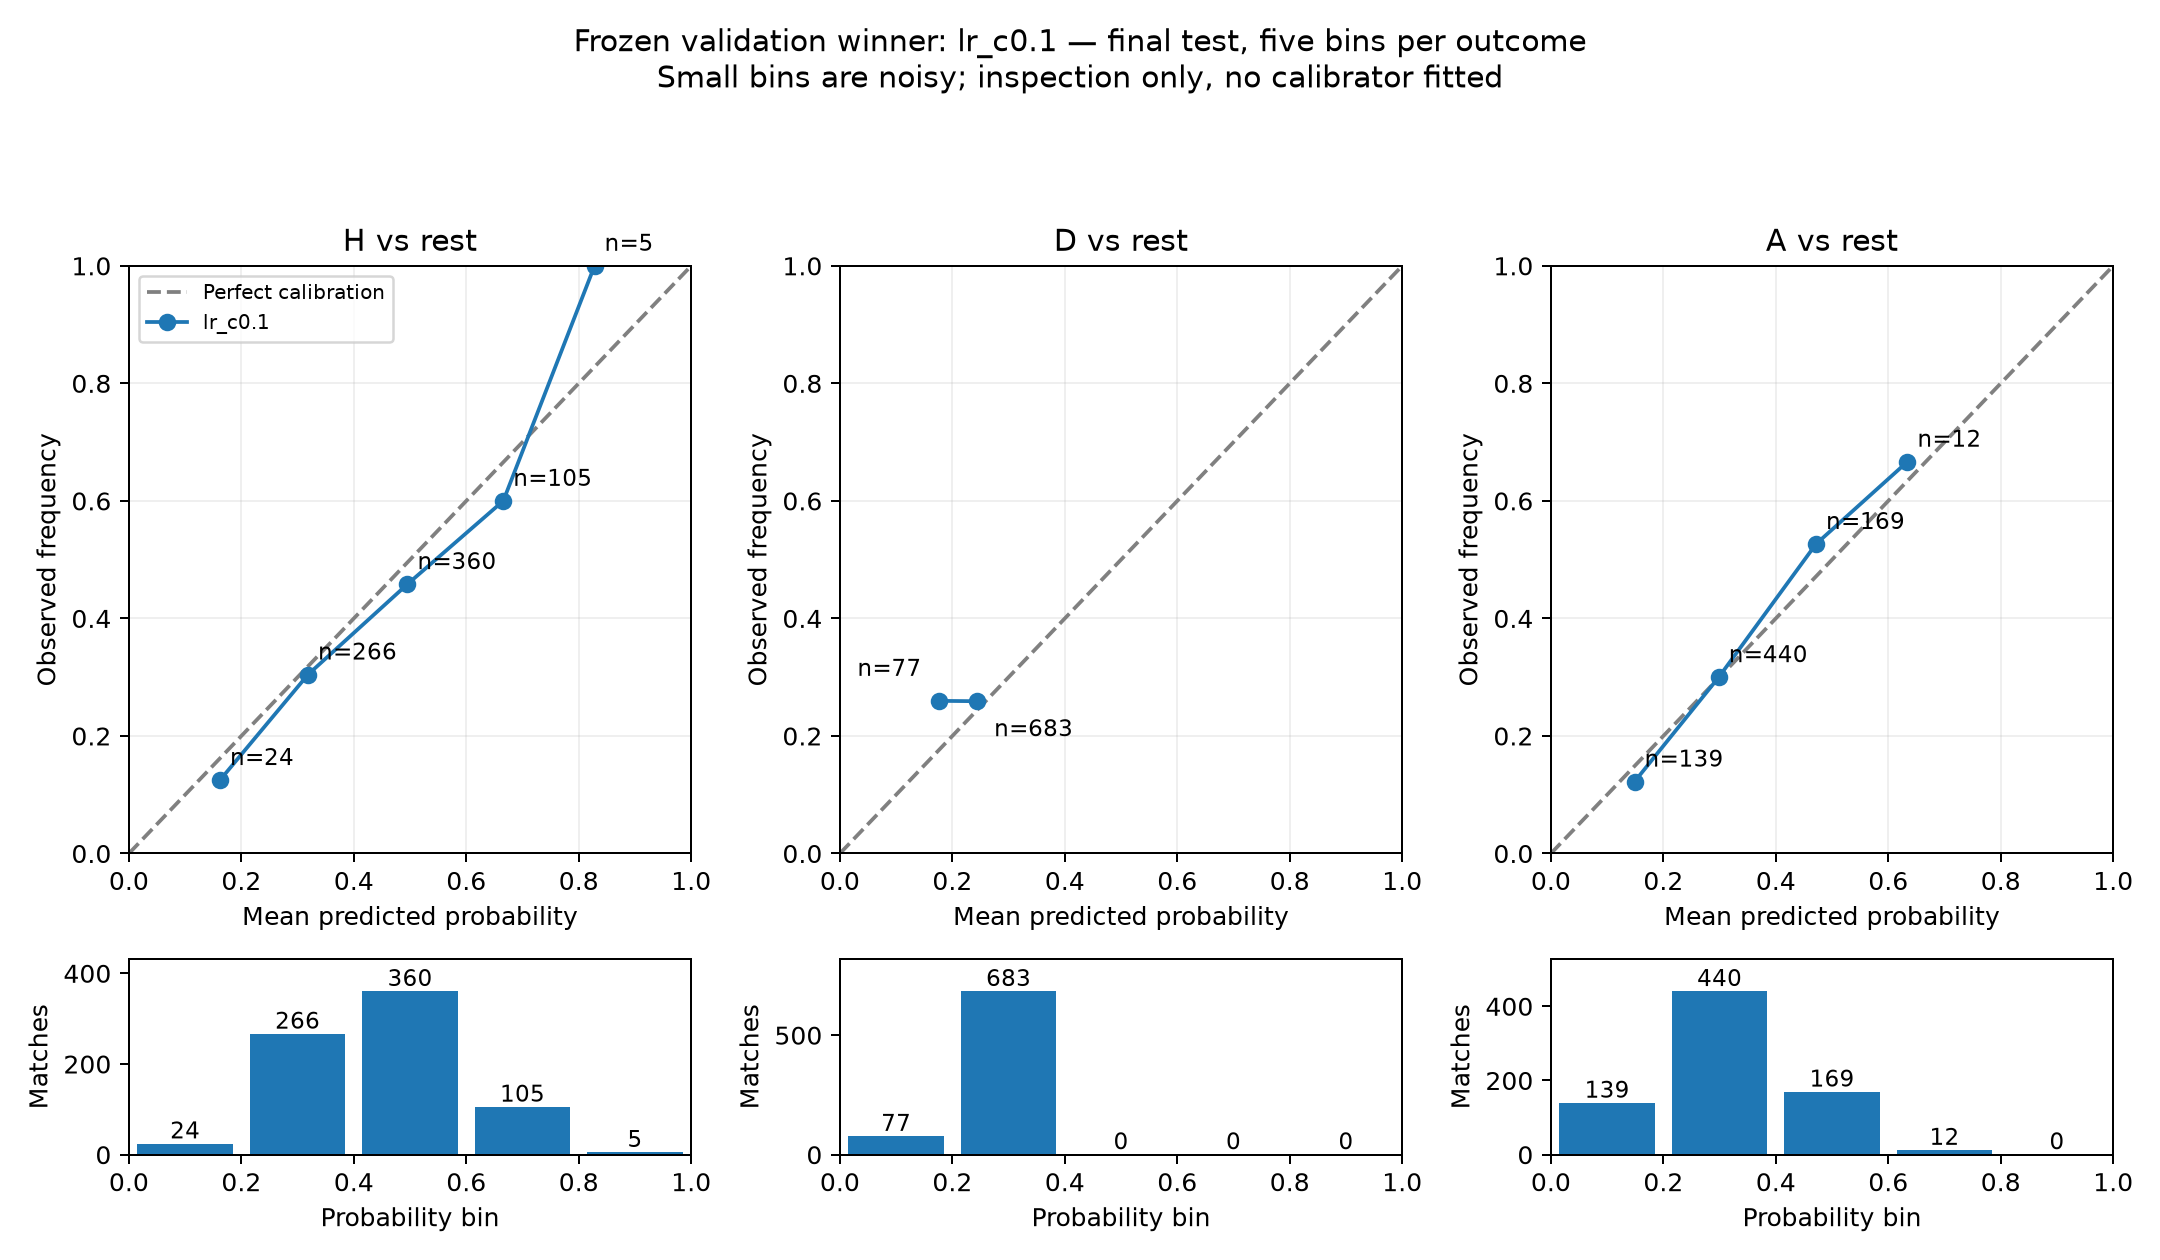

,outcome,bin,lower,upper,count,mean_probability,observed_frequency
0,H,1,0.0,0.2,24,0.162030,0.125000
1,H,2,0.2,0.4,266,0.318562,0.304511
2,H,3,0.4,0.6,360,0.495439,0.458333
3,H,4,0.6,0.8,105,0.665802,0.600000
4,H,5,0.8,1.0,5,0.828121,1.000000
5,D,1,0.0,0.2,77,0.176083,0.259740
6,D,2,0.2,0.4,683,0.243158,0.259151
7,D,3,0.4,0.6,0,NaN,NaN
8,D,4,0.6,0.8,0,NaN,NaN
9,D,5,0.8,1.0,0,NaN,NaN


In [18]:
from IPython.display import Image
calibration = pd.read_csv(ROOT / "reports/calibration_bins.csv")
assert calibration.groupby("outcome")["count"].sum().eq(760).all()
display(Image(filename=str(ROOT / "reports/calibration.png")))
display(calibration)

### Error analysis, with group sizes

This is descriptive analysis after final-test access, not a new selection or tuning experiment. The low-history threshold was fixed before opening test data: either team has fewer than five eligible previous matches.

**Draws:** the winner picked a draw once, and that match was a draw. Precision is therefore 1/1 = **100%**, but recall is only **1/197 = 0.51%**. Precision based on one prediction is weak evidence. The remaining 196 draws were picked as H or A. The model still assigns draw probability in every forecast; argmax recall measures winner picking, while log loss measures the probability assigned to the actual draw.

**History:** low-history fixtures have log loss **1.157225 across 28 matches**, versus **1.031521 across 732 full-history matches**. Six zero-history fixtures form a subset of the 28; their small count limits conclusions. The outcome groups and history groups overlap, so their counts should not be added together.

The largest loss is Burnley–Sunderland on August 23, 2025: the winner assigned Burnley just **2.89%** home-win probability, but Burnley won 2–0; both teams had one eligible previous match. This identifies an error in a small-history fixture, not a proven cause or a reason to retune on the test set.

In [19]:
error_groups_table = pd.read_csv(ROOT / "reports/test_error_groups.csv")
display(error_groups_table)
display(pd.read_csv(ROOT / "reports/test_error_examples.csv"))
draws = classified.loc[(classified.season == "combined") & (classified.subset == "all_test")
                       & (classified.forecast == final_summary["winner_id"]) & (classified.outcome == "D")]
display(draws)

,season,group,matches,log_loss,rps,accuracy,correct_predictions
0,2024/25,all,380,1.014637,0.211637,0.510526,194
1,2024/25,actual_H,155,0.719280,0.173395,0.812903,126
2,2024/25,actual_D,93,1.456458,0.169897,0.010753,1
3,2024/25,actual_A,132,1.050174,0.285951,0.507576,67
4,2024/25,low_history_either_team_lt5,14,0.961232,0.156541,0.571429,8
5,2024/25,full_history_both_5,366,1.016680,0.213745,0.508197,186
6,2024/25,zero_history_either_team,3,0.829032,0.109140,0.666667,2
7,2025/26,all,380,1.057667,0.217480,0.465789,177
8,2025/26,actual_H,162,0.788978,0.193016,0.777778,126
9,2025/26,actual_D,104,1.441566,0.163081,0.000000,0


,Season,Date,HomeTeam,AwayTeam,FTR,FTHG,FTAG,fixture_id,p_H,p_D,p_A,predicted_result,log_loss,home_history_count_5,away_history_count_5
0,2025/26,2025-08-23,Burnley,Sunderland,H,2,0,2025/26|2025-08-23|Burnley|Sunderland,0.028880,0.308727,0.662393,A,3.544607,1,1
1,2025/26,2025-08-23,Man City,Tottenham,A,0,2,2025/26|2025-08-23|Man City|Tottenham,0.763604,0.147738,0.088658,H,2.422971,5,5
2,2024/25,2024-08-24,Crystal Palace,West Ham,A,0,2,2024/25|2024-08-24|Crystal Palace|West Ham,0.754189,0.151008,0.094803,H,2.355953,5,5
3,2024/25,2025-02-22,Arsenal,West Ham,A,0,1,2024/25|2025-02-22|Arsenal|West Ham,0.703082,0.178901,0.118017,H,2.136923,5,5
4,2024/25,2024-11-10,Tottenham,Ipswich,A,1,2,2024/25|2024-11-10|Tottenham|Ipswich,0.698066,0.182022,0.119911,H,2.121004,5,5


,season,subset,forecast,outcome,precision,recall,f1,support,predicted_count,true_positive
55,combined,all_test,lr_c0.1,D,1.0,0.005076,0.010101,197,1,1


### One actual final-test prediction

For **Man United–Fulham, August 16, 2024**, the winner gives H **41.65%**, D **21.87%**, A **36.47%**. Its largest probability is H, and the actual result is H. The match contributes **−ln(0.41651727) = 0.87582735** to the mean log loss. A correct argmax does not imply certainty or a near-zero probability loss.

In [20]:
test_example = json.loads((ROOT / "reports/test_example.json").read_text())
print("Fixture:", test_example["fixture"])
display(pd.DataFrame([test_example["probabilities_h_d_a"]]))
print("Prediction:", test_example["predicted_result"], "Actual:", test_example["actual_result"])
np.testing.assert_allclose(multiclass_log_loss([test_example["actual_result"]],
                            [list(test_example["probabilities_h_d_a"].values())]), test_example["log_loss"])
print("Verified single-match log loss:", test_example["log_loss"])
final_predictions = pd.read_csv(ROOT / "reports/test_predictions.csv")
assert len(final_predictions) == 760 * 5
assert final_predictions.split.eq("test").all()
assert final_predictions.groupby("forecast").fixture_id.nunique().eq(760).all()
np.testing.assert_allclose(final_predictions[["p_H", "p_D", "p_A"]].sum(axis=1), 1)
print("Exported", len(final_predictions), "forecast rows for", final_predictions.fixture_id.nunique(), "fixtures.")

Fixture: {'Season': '2024/25', 'Date': '2024-08-16', 'HomeTeam': 'Man United', 'AwayTeam': 'Fulham'}
Prediction: H Actual: H
Verified single-match log loss: 0.8758273534893548
Exported 3800 forecast rows for 760 fixtures.


,H,D,A
0,0.416517,0.218744,0.364739


Understanding checkpoint:
1. Why compare models and bookmakers on identical valid-odds fixtures, even though this snapshot happens to have 100% coverage?
2. The winner has 100% draw precision but about 0.51% draw recall. What do those numbers mean, and why does 100% precision not establish good draw forecasting?

Stop after milestone 5. Further experiments would reuse an already-opened final test and must be disclosed as exploratory; the original winner and evaluation remain frozen.